# Exploratory Data Analysis - Telco Customer Churn

Provenance: [IBM sample dataset](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv) (7,043 customers, 21 columns), fetched by `scripts/download_data.sh` (SHA256-pinned).

Scope: this notebook is **exploratory only**, deliberately off the critical path. Every transformation decided here gets implemented properly (and unit-tested) in the shared preprocessing pipeline (`training/preprocessing.py`, Etape 2).

Questions:

1. How balanced is the target?
2. Which data-quality defects need handling, and how?
3. Which features carry signal?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../training/data/Telco-Customer-Churn.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print(f"rows: {df.shape[0]:,} | columns: {df.shape[1]}")
df.info()
df.describe().T

rows: 7,043 | columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


## 1. Target balance

Churn
No     5174
Yes    1869

churn rate: 26.54%


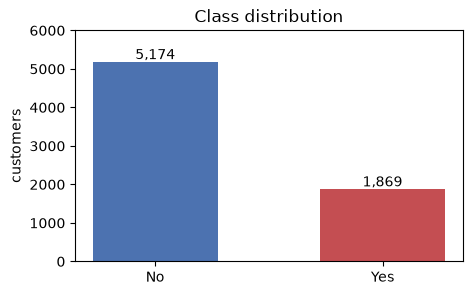

In [3]:
counts = df["Churn"].value_counts()
churn_rate = float((df["Churn"] == "Yes").mean())
df["churn_flag"] = (df["Churn"] == "Yes").astype(int)

print(counts.to_string())
print(f"\nchurn rate: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(counts.index, counts.to_numpy(), color=["#4c72b0", "#c44e52"], width=0.55)
for i, v in enumerate(counts.to_numpy()):
    ax.text(i, v + 80, f"{v:,}", ha="center")
ax.set_ylim(0, 6000)
ax.set_ylabel("customers")
ax.set_title("Class distribution")
plt.show()

**Finding**: 26.5% positives - moderately imbalanced. Carried forward: stratified split, **recall + ROC-AUC as primary metrics** (accuracy would flatter a model that ignores churners), and `class_weight="balanced"` consideration for the model (Etape 3).

## 2. Data quality

In [4]:
total_charges = pd.to_numeric(df["TotalCharges"], errors="coerce")
blank = total_charges.isna()

print(f"rows with non-numeric TotalCharges: {int(blank.sum())}")
print(f"tenure of these rows: {sorted(df.loc[blank, 'tenure'].unique().tolist())}")

df.loc[blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

rows with non-numeric TotalCharges: 11
tenure of these rows: [0]


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


**Finding**: the 11 defective `TotalCharges` are exactly the `tenure == 0` customers - brand-new accounts with no billing cycle closed yet.

**Decision**: impute `0` (semantically exact), inside the shared scikit-learn pipeline - not row deletion, which would throw away real customers.

Also: `customerID` is a pure identifier - dropped from features.

## 3. Feature landscape

In [5]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.drop(["customerID", "Churn"])
pd.DataFrame(
    {
        "n_unique": [df[c].nunique() for c in cat_cols],
        "values": [", ".join(map(str, df[c].unique().tolist())) for c in cat_cols],
    },
    index=list(cat_cols),
)

,n_unique,values
gender,2,"Female, Male"
Partner,2,"Yes, No"
Dependents,2,"No, Yes"
PhoneService,2,"No, Yes"
MultipleLines,3,"No phone service, No, Yes"
InternetService,3,"DSL, Fiber optic, No"
OnlineSecurity,3,"No, Yes, No internet service"
OnlineBackup,3,"Yes, No, No internet service"
DeviceProtection,3,"No, Yes, No internet service"
TechSupport,3,"No, Yes, No internet service"


**Finding**: every categorical feature is low-cardinality -> one-hot encoding with `handle_unknown="ignore"`. `Contract` has a natural order (month-to-month < one-year < two-year); ordinal encoding is a documented alternative, simplicity wins here.

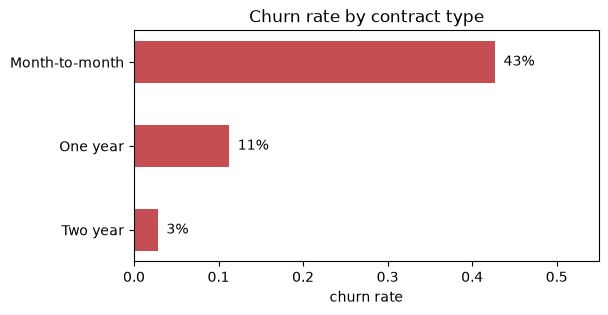

In [6]:
rates = df.groupby("Contract")["churn_flag"].mean().sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(rates.index, rates.to_numpy(), color="#c44e52", height=0.5)
for y, v in enumerate(rates.to_numpy()):
    ax.text(v + 0.01, y, f"{v:.0%}", va="center")
ax.set_xlim(0, 0.55)
ax.set_xlabel("churn rate")
ax.set_title("Churn rate by contract type")
plt.show()

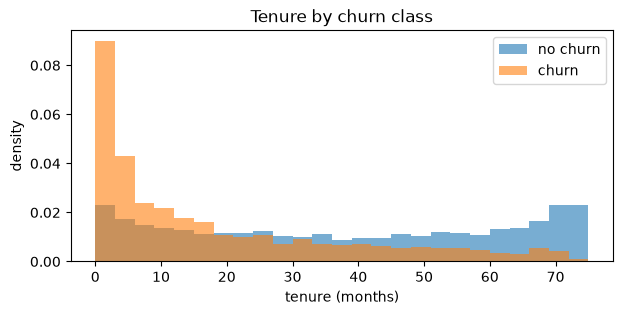

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
bins = range(0, 76, 3)
ax.hist(df.loc[df["Churn"] == "No", "tenure"], bins=bins, alpha=0.6, label="no churn", density=True)
ax.hist(df.loc[df["Churn"] == "Yes", "tenure"], bins=bins, alpha=0.6, label="churn", density=True)
ax.set_xlabel("tenure (months)")
ax.set_ylabel("density")
ax.legend()
ax.set_title("Tenure by churn class")
plt.show()

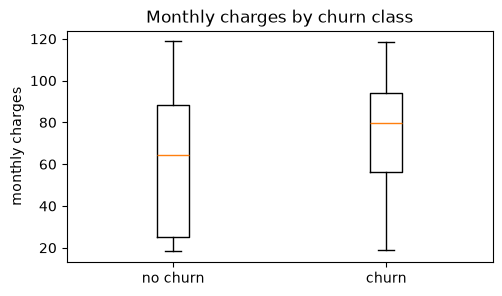

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.boxplot(
    [
        df.loc[df["Churn"] == "No", "MonthlyCharges"],
        df.loc[df["Churn"] == "Yes", "MonthlyCharges"],
    ],
    tick_labels=["no churn", "churn"],
)
ax.set_ylabel("monthly charges")
ax.set_title("Monthly charges by churn class")
plt.show()

In [9]:
signal = (
    df[["tenure", "MonthlyCharges", "SeniorCitizen", "churn_flag"]]
    .assign(total_charges=total_charges.fillna(0.0))
    .corr()["churn_flag"]
    .drop("churn_flag")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
signal

tenure           -0.352229
total_charges    -0.198324
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: churn_flag, dtype: float64

## Findings -> feature engineering decisions

| Observation | Decision (implemented in `training/preprocessing.py`, Etape 2) |
|---|---|
| Target 26.5% imbalanced | Stratified split (fixed seed); recall + ROC-AUC primary |
| 11 blank `TotalCharges` <-> `tenure == 0` | Impute `0` inside the shared pipeline |
| `customerID` pure identifier | Dropped from features |
| Low-cardinality nominals | `OneHotEncoder(handle_unknown="ignore")` |
| `Contract` naturally ordered | One-hot kept; ordinal documented as alternative |
| Heterogeneous numeric scales | `StandardScaler` retained (logistic baseline; neutral for trees) |

Full rationale: [`docs/feature-engineering.md`](../docs/feature-engineering.md).